# Chapter 7: Introduction to Probability Models


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 7.1-7.4: discrete and continuous probability models, statistics, the central limit theorem, and diffusion.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 7.1 Discrete probability: group testing of diodes

For a group of \(n>1\) diodes, the expected cost per diode is

\[
A(n)=\frac{4}{n}+6-5(0.997)^n.
\]

The decision variable is discrete, so we enumerate plausible group sizes rather than pretending a fractional diode is an exciting manufacturing innovation.


Best integer group size: n=17, expected cost=1.4843 cents/diode


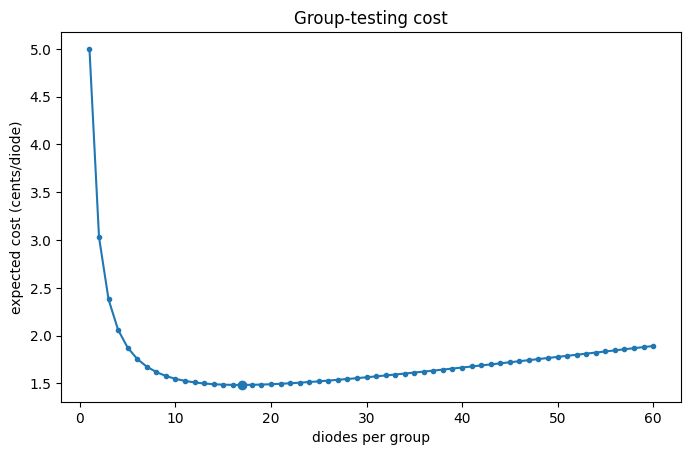

In [2]:
def diode_cost(n, failure_rate=0.003):
    n = np.asarray(n, dtype=float)
    return 4 / n + 6 - 5 * (1 - failure_rate) ** n

group_sizes = np.arange(1, 61)
costs = np.where(group_sizes == 1, 5.0, diode_cost(group_sizes))
best_n = int(group_sizes[np.argmin(costs)])
best_cost = float(np.min(costs))

print(f"Best integer group size: n={best_n}, expected cost={best_cost:.4f} cents/diode")
assert best_n == 17

plt.plot(group_sizes, costs, marker="o", markersize=3)
plt.scatter([best_n], [best_cost], zorder=3)
plt.xlabel("diodes per group")
plt.ylabel("expected cost (cents/diode)")
plt.title("Group-testing cost")
plt.show()


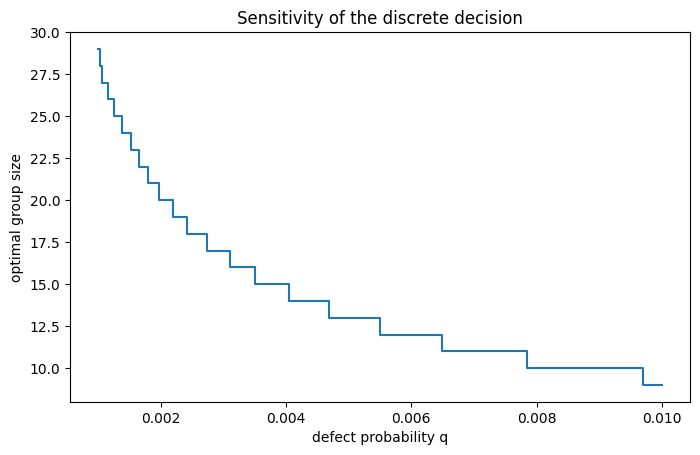

In [3]:
q_grid = np.linspace(0.001, 0.010, 200)
optimal_n = []
optimal_cost = []
for q in q_grid:
    candidate_cost = np.where(group_sizes == 1, 5.0, diode_cost(group_sizes, failure_rate=q))
    index = np.argmin(candidate_cost)
    optimal_n.append(group_sizes[index])
    optimal_cost.append(candidate_cost[index])

plt.step(q_grid, optimal_n, where="mid")
plt.xlabel("defect probability q")
plt.ylabel("optimal group size")
plt.title("Sensitivity of the discrete decision")
plt.show()


## Expected value and the strong law: two dice


Expected dice sum: 6.999999999999998


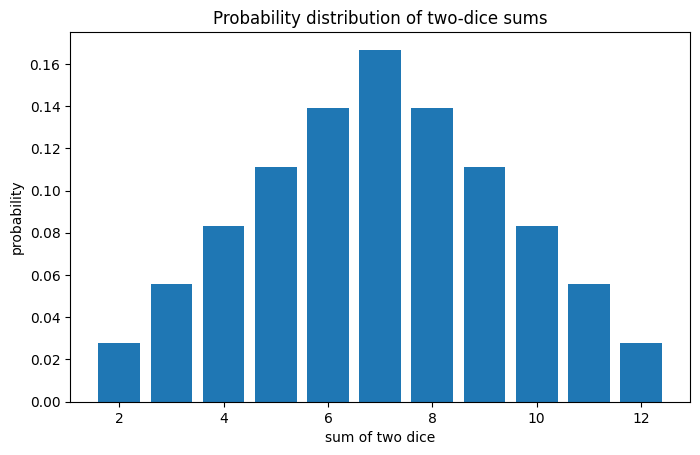

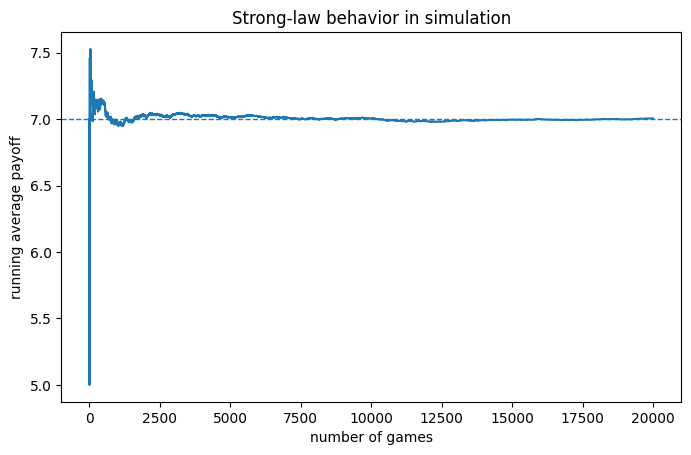

In [4]:
from scipy import stats

outcomes = np.arange(2, 13)
counts = np.array([1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1])
probabilities = counts / 36
expected_sum = np.sum(outcomes * probabilities)
print("Expected dice sum:", expected_sum)

plt.bar(outcomes, probabilities)
plt.xlabel("sum of two dice")
plt.ylabel("probability")
plt.title("Probability distribution of two-dice sums")
plt.show()

rolls = rng.integers(1, 7, size=(20_000, 2)).sum(axis=1)
running_mean = np.cumsum(rolls) / np.arange(1, len(rolls) + 1)
plt.plot(running_mean)
plt.axhline(expected_sum, linestyle="--", linewidth=1)
plt.xlabel("number of games")
plt.ylabel("running average payoff")
plt.title("Strong-law behavior in simulation")
plt.show()


## 7.2 Continuous probability and memorylessness

The exponential distribution is the continuous waiting-time model used throughout the book. Its survival probability satisfies

\[
P(T>s+t\mid T>s)=P(T>t).
\]


In [5]:
rate = 2.0
s, extra = 0.7, 0.9
sample = rng.exponential(1 / rate, size=1_000_000)
conditional_estimate = np.mean(sample[sample > s] > s + extra)
theoretical = np.exp(-rate * extra)

memoryless_check = pd.Series({
    "simulation": conditional_estimate,
    "theory": theoretical,
    "absolute error": abs(conditional_estimate - theoretical),
})
display(memoryless_check.to_frame("value"))


,value
simulation,0.166170
theory,0.165299
absolute error,0.000871


## 7.3 Central limit theorem: monthly fire calls

An average of 171 calls per month is modeled by exponential interarrival times, equivalently a Poisson count over a fixed month. The chapter's normal approximation treats roughly 147-198 calls as ordinary 95% variation.


Book-style 95% normal-variation range: 147 to 199 calls
Exact central Poisson interval: (np.float64(146.0), np.float64(197.0))
Simulated probability of 153 or fewer calls: 0.088815


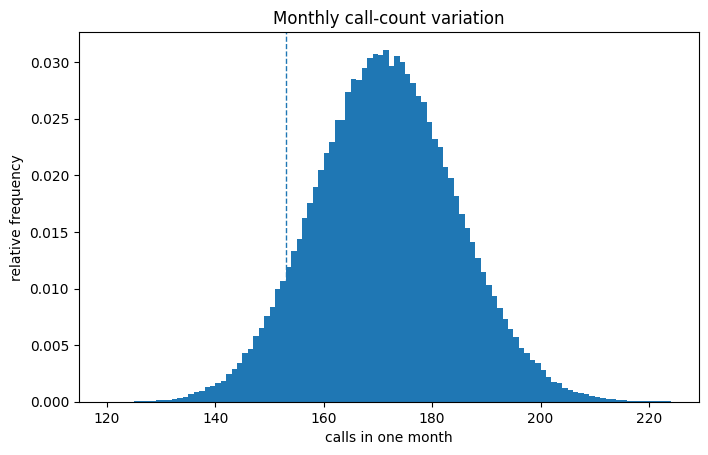

In [6]:
lam = 171
candidate_counts = np.arange(1, 350)
lower_time = candidate_counts / lam - 2 * np.sqrt(candidate_counts) / lam
upper_time = candidate_counts / lam + 2 * np.sqrt(candidate_counts) / lam
normal_counts = candidate_counts[(lower_time <= 1) & (upper_time >= 1)]
print(f"Book-style 95% normal-variation range: {normal_counts.min()} to {normal_counts.max()} calls")

poisson_interval = stats.poisson.interval(0.95, lam)
print("Exact central Poisson interval:", poisson_interval)

simulated_counts = rng.poisson(lam, size=200_000)
print("Simulated probability of 153 or fewer calls:", np.mean(simulated_counts <= 153))

plt.hist(simulated_counts, bins=np.arange(120, 225), density=True)
plt.axvline(153, linestyle="--", linewidth=1)
plt.xlabel("calls in one month")
plt.ylabel("relative frequency")
plt.title("Monthly call-count variation")
plt.show()


## 7.4 Diffusion

The point-source solution

\[
C(x,t)=\frac{1}{\sqrt{2\pi Dt}}\exp\left(-\frac{x^2}{2Dt}\right)
\]

solves \(C_t=(D/2)C_{xx}\). SymPy verifies the PDE symbolically, then SciPy solves the chapter's airborne-pollution optimization.


In [7]:
x, t, D = sp.symbols("x t D", positive=True, real=True)
C = sp.exp(-x**2 / (2 * D * t)) / sp.sqrt(2 * sp.pi * D * t)
pde_residual = sp.simplify(sp.diff(C, t) - D / 2 * sp.diff(C, x, 2))
print("Diffusion PDE residual:")
display(pde_residual)
assert pde_residual == 0


Diffusion PDE residual:


0

In [8]:
from scipy.optimize import brentq, minimize_scalar

def town_pollution(time, velocity=3.0):
    time = np.asarray(time)
    return 20 / np.sqrt(time) * np.exp(-((10 - velocity * time) ** 2) / (0.5 * time))

maximum = minimize_scalar(lambda time: -town_pollution(time), bounds=(0.01, 20), method="bounded")


In [9]:
max_time = maximum.x
max_level = -maximum.fun
root_early = brentq(lambda z: town_pollution(z) - 1, 0.01, max_time)
root_late = brentq(lambda z: town_pollution(z) - 1, max_time, 20)

pollution_summary = pd.Series({
    "peak concentration (safe-level multiples)": max_level,
    "time of peak (hours)": max_time,
    "unsafe begins (hours)": root_early,
    "safe again (hours)": root_late,
})
display(pollution_summary.to_frame("value"))

assert np.isclose(max_level, 10.97, atol=0.05)
assert np.isclose(max_time, 3.3, atol=0.1)
assert np.isclose(root_late, 4.1, atol=0.1)


,value
peak concentration (safe-level multiples),10.965868
time of peak (hours),3.319473
unsafe begins (hours),2.719322
safe again (hours),4.052300


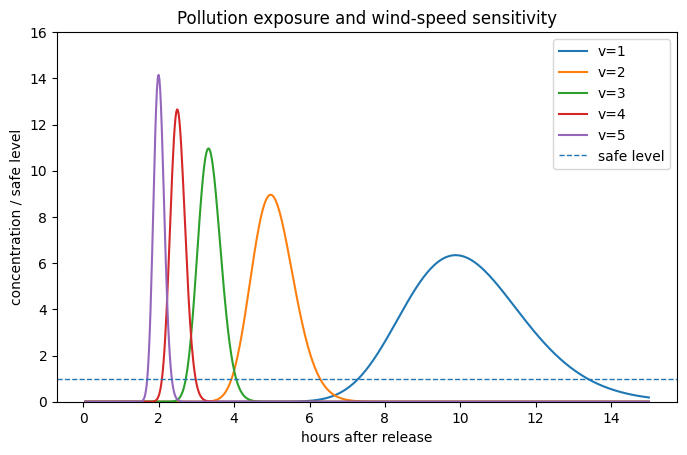

In [10]:
time_grid = np.linspace(0.05, 15, 700)
for velocity in [1, 2, 3, 4, 5]:
    plt.plot(time_grid, town_pollution(time_grid, velocity), label=f"v={velocity}")
plt.axhline(1, linestyle="--", linewidth=1, label="safe level")
plt.xlabel("hours after release")
plt.ylabel("concentration / safe level")
plt.title("Pollution exposure and wind-speed sensitivity")
plt.ylim(0, 16)
plt.legend()
plt.show()


## Chapter checkpoint

Expected values summarize repeated outcomes, while the law of large numbers and central limit theorem quantify what repeated measurements do. Diffusion then joins the deterministic PDE and probabilistic random-walk descriptions of the same spreading process.
